
PROCESSANDO AÇÃO: PETR4.SA


/tmp/ipykernel_156/3179347014.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


Treinando o modelo...
--> RMSE alcançado: 0.72


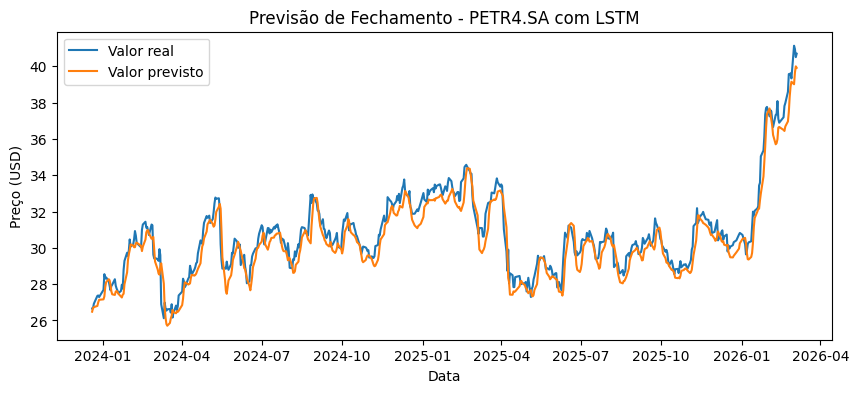

--> Previsão de preço da ação para o próximo dia: $39.82


PROCESSANDO AÇÃO: VALE3.SA


/tmp/ipykernel_156/3179347014.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


Treinando o modelo...
--> RMSE alcançado: 1.18


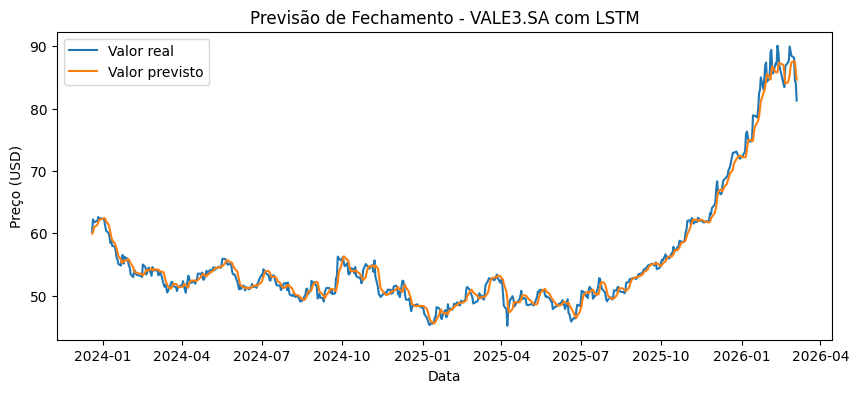

--> Previsão de preço da ação para o próximo dia: $82.67


PROCESSANDO AÇÃO: ITUB4.SA


/tmp/ipykernel_156/3179347014.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


Treinando o modelo...
--> RMSE alcançado: 0.72


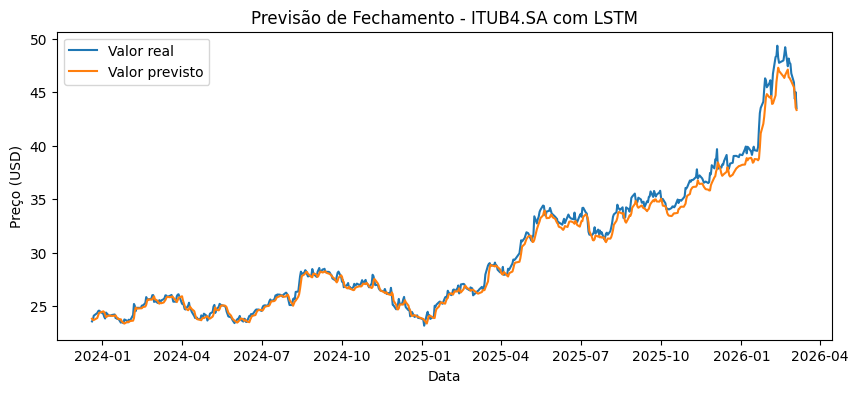

--> Previsão de preço da ação para o próximo dia: $42.55


PROCESSANDO AÇÃO: BBDC4.SA


/tmp/ipykernel_156/3179347014.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


Treinando o modelo...
--> RMSE alcançado: 0.29


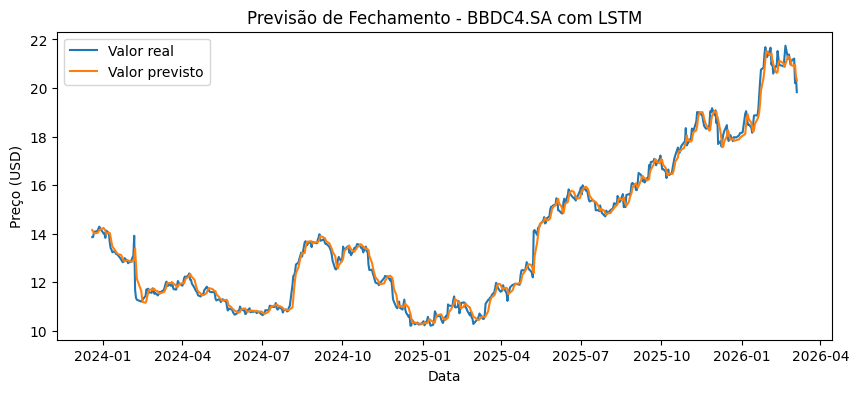

--> Previsão de preço da ação para o próximo dia: $19.92


PROCESSANDO AÇÃO: ABEV3.SA


/tmp/ipykernel_156/3179347014.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


Treinando o modelo...
--> RMSE alcançado: 0.16


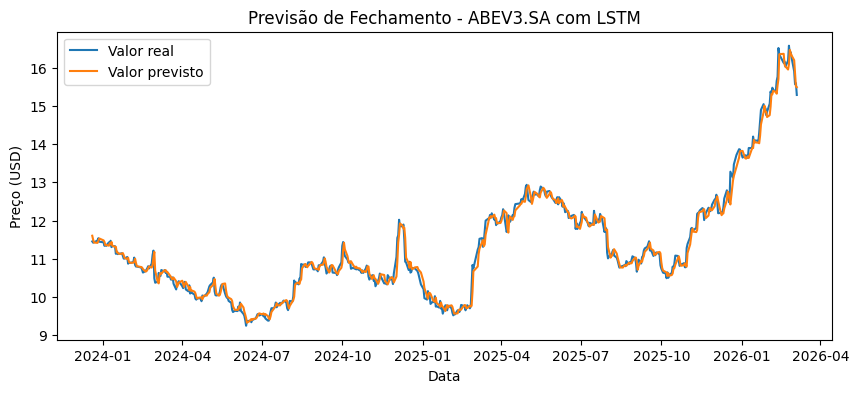

--> Previsão de preço da ação para o próximo dia: $15.28



In [2]:
# 1. IMPORTAÇÕES
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping

# 2. CONFIGURAÇÕES INICIAIS
tickers = ["PETR4.SA", "VALE3.SA", "ITUB4.SA", "BBDC4.SA", "ABEV3.SA"]
start_date = "2015-01-01"
end_date = None
window_size = 30

# Função de criação de janelas temporais
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# 3. LOOP DE PROCESSAMENTO PARA CADA AÇÃO
for ticker in tickers:
    print("\n" + "="*60)
    print("PROCESSANDO AÇÃO: " + ticker)
    print("="*60)

    # Coleta dos dados
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    series = df[['Close']].dropna()

    # Normalização dos dados
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series.values)

    # Criação das janelas temporais
    X, y = create_windows(series_scaled, window_size)

    # Separação Treino / Teste (80% treino / 20% teste)
    split = int(0.8 * len(X))
    X_train = X[:split]
    X_test = X[split:]
    y_train = y[:split]
    y_test = y[split:]

    # Construção do Modelo LSTM
    model = Sequential()
    model.add(Input(shape=(window_size, 1)))
    model.add(LSTM(50, activation='tanh'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    # Treinamento do Modelo com Parada Antecipada
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    print("Treinando o modelo...")
    history = model.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=50,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    # Avaliação do Modelo
    y_pred = model.predict(X_test, verbose=0)

    y_test_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred)

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    print("--> RMSE alcançado: {:.2f}".format(rmse))

    # Visualização das previsões
    plt.figure(figsize=(10, 4))
    plt.plot(series.index[-len(y_test):], y_test_inv, label="Valor real")
    plt.plot(series.index[-len(y_test):], y_pred_inv, label="Valor previsto")
    plt.title("Previsão de Fechamento - " + ticker + " com LSTM")
    plt.xlabel("Data")
    plt.ylabel("Preço (USD)")
    plt.legend()
    plt.show()

    # Previsão do próximo dia
    last_window = series_scaled[-window_size:]
    last_window = last_window.reshape(1, window_size, 1)

    next_day_pred = model.predict(last_window, verbose=0)
    next_day_price = scaler.inverse_transform(next_day_pred)

    print("--> Previsão de preço da ação para o próximo dia: ${:.2f}\n".format(next_day_price[0][0]))